### Exploratory Data Analysis (EDA)



In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import zipfile

In [2]:
with zipfile.ZipFile(r"C:\Users\ANTARA\Downloads\archive (2).zip") as z:
    train_df = pd.read_csv(z.open("train.csv"))
    store_df = pd.read_csv(z.open("store.csv"))

C:\Users\ANTARA\AppData\Local\Temp\ipykernel_32744\1137355779.py:2: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train_df = pd.read_csv(z.open("train.csv"))


In [3]:
train_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


### Sales Distribution Analysis

In [8]:
# Convert Date column to datetime format
train_df["Date"] = pd.to_datetime(train_df["Date"])

# Handle missing values in store dataset
store_df["CompetitionDistance"] = store_df["CompetitionDistance"].fillna(
    store_df["CompetitionDistance"].median()
)

store_df["CompetitionOpenSinceMonth"] = store_df["CompetitionOpenSinceMonth"].fillna(0)
store_df["CompetitionOpenSinceYear"] = store_df["CompetitionOpenSinceYear"].fillna(0)

store_df["Promo2SinceWeek"] = store_df["Promo2SinceWeek"].fillna(0)
store_df["Promo2SinceYear"] = store_df["Promo2SinceYear"].fillna(0)
store_df["PromoInterval"] = store_df["PromoInterval"].fillna("No Promo")

#### Merge Sales and Store Datasets

In [9]:
pricing_df = pd.merge(
    train_df,
    store_df,
    on="Store",
    how="left"
)

In [10]:
pricing_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,No Promo
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,No Promo
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,No Promo


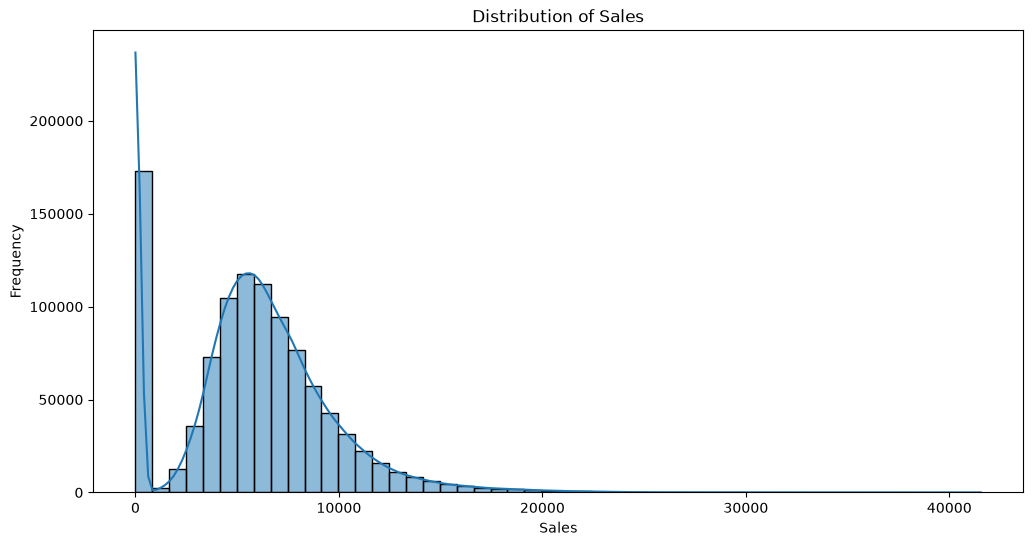

In [11]:
plt.figure(figsize=(12, 6))
sns.histplot(
      data=pricing_df,
      x="Sales",
      bins=50,
      kde='True'
)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()


### Daily Sales Trend Analysis

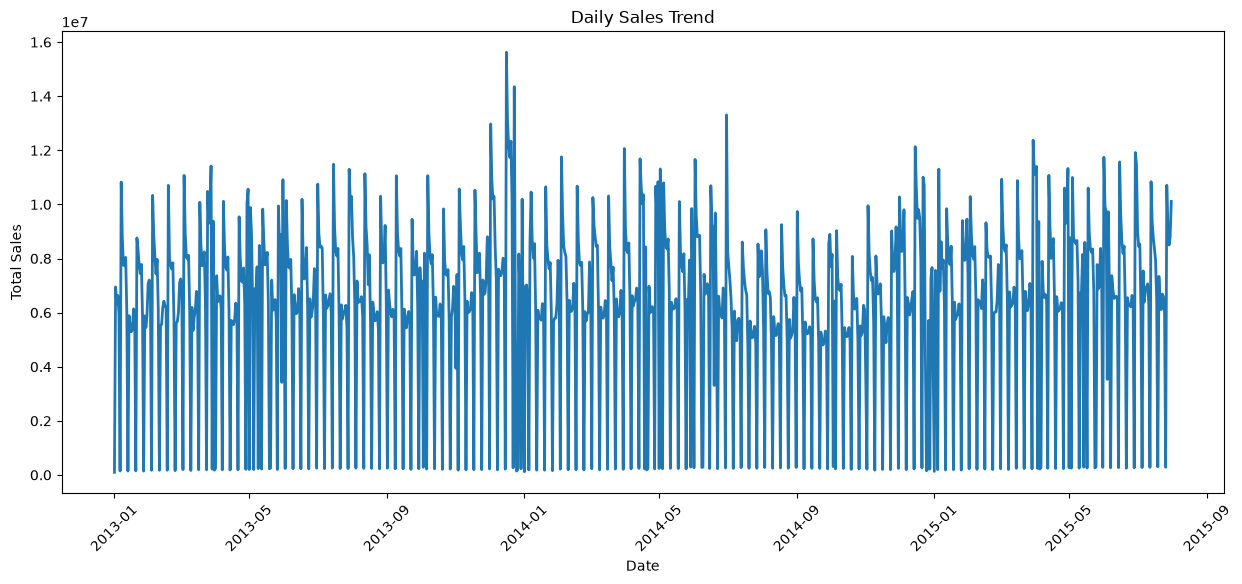

In [10]:
daily_sales = pricing_df.groupby("Date")["Sales"].sum().reset_index()
plt.figure(figsize=(15, 6))

plt.plot(
    daily_sales["Date"],
    daily_sales["Sales"],
    linewidth=2
)

plt.title("Daily Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.show()

### Monthly Sales Analysis

In [12]:
pricing_df["Month"] = pricing_df["Date"].dt.month

In [13]:
monthly_sales = pricing_df.groupby("Month")["Sales"].sum().reset_index()

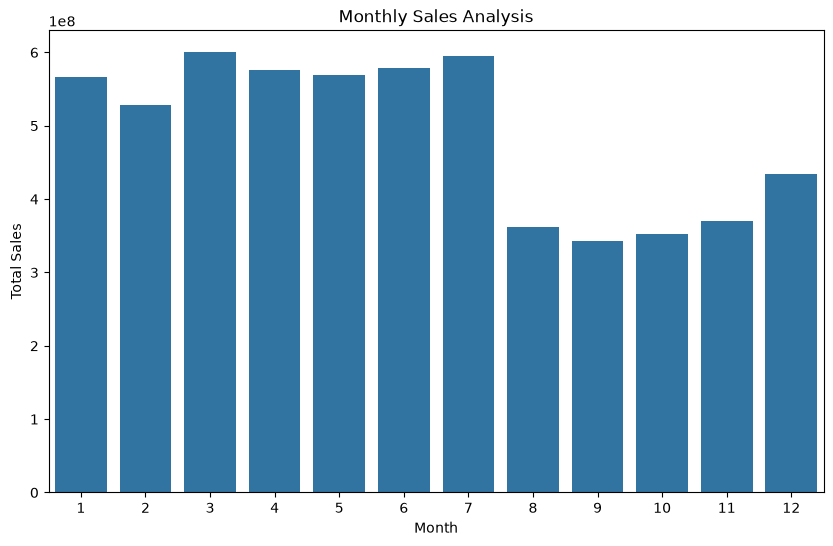

In [14]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=monthly_sales,
    x="Month",
    y="Sales"
)

plt.title("Monthly Sales Analysis")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.show()

Promotion Impact Analysis

In [15]:
promo_sales = pricing_df.groupby("Promo")["Sales"].mean().reset_index()

promo_sales

,Promo,Sales
0,0,4406.050805
1,1,7991.152046


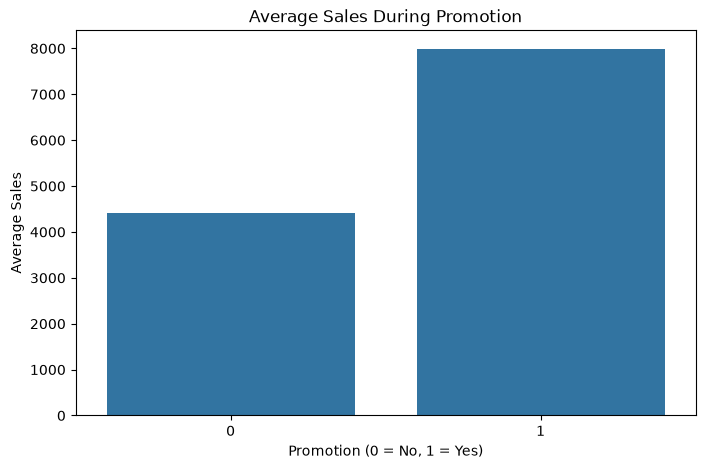

In [16]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=promo_sales,
    x="Promo",
    y="Sales"
)

plt.title("Average Sales During Promotion")
plt.xlabel("Promotion (0 = No, 1 = Yes)")
plt.ylabel("Average Sales")

plt.show()

Store Type Analysis

In [18]:
store_type_sales = pricing_df.groupby("StoreType")["Sales"].mean().reset_index()

store_type_sales

,StoreType,Sales
0,a,5738.179710
1,b,10058.837334
2,c,5723.629246
3,d,5641.819243


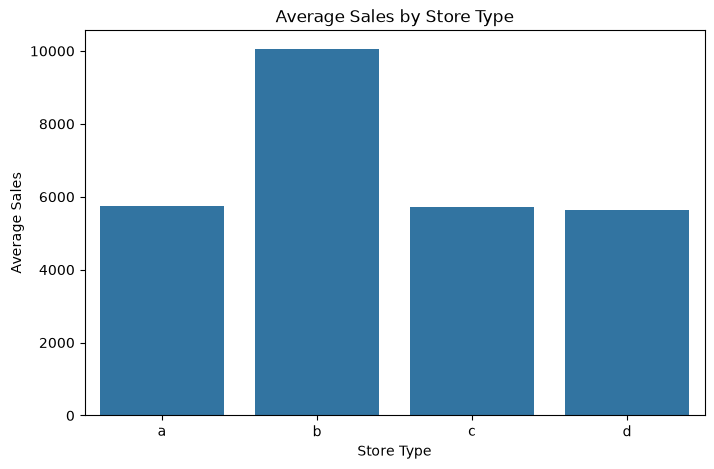

In [19]:

plt.figure(figsize=(8,5))

sns.barplot(
    data=store_type_sales,
    x="StoreType",
    y="Sales"
)

plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")

plt.show()

Assortment Analysis

In [20]:
assortment_sales = pricing_df.groupby("Assortment")["Sales"].mean().reset_index()

assortment_sales

,Assortment,Sales
0,a,5481.026096
1,b,8553.931999
2,c,6058.676567


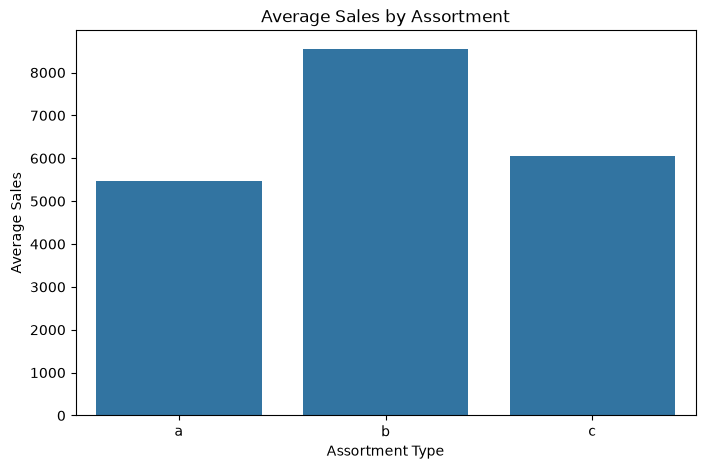

In [21]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=assortment_sales,
    x="Assortment",
    y="Sales"
)

plt.title("Average Sales by Assortment")
plt.xlabel("Assortment Type")
plt.ylabel("Average Sales")

plt.show()

 Competition Distance Analysis

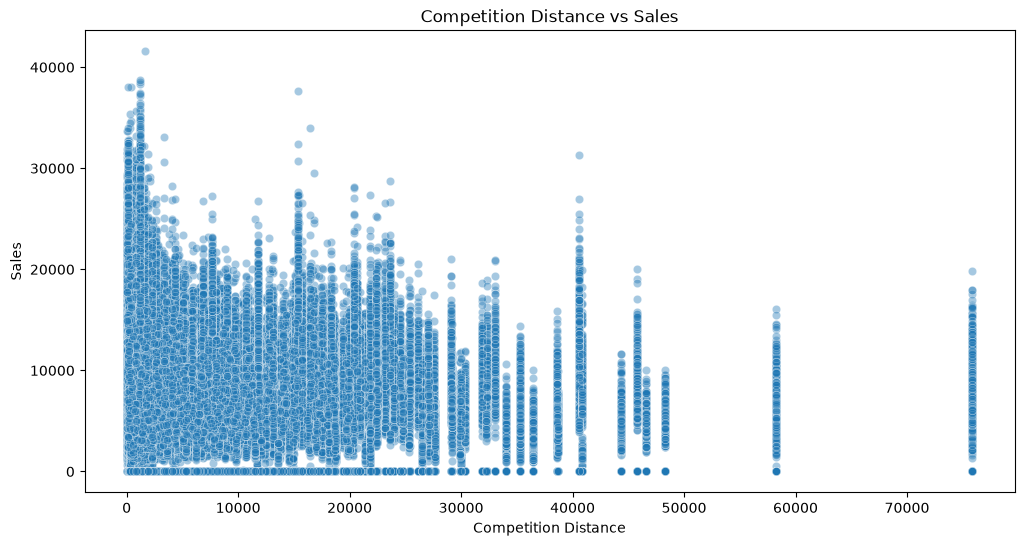

In [22]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=pricing_df,
    x="CompetitionDistance",
    y="Sales",
    alpha=0.4
)

plt.title("Competition Distance vs Sales")
plt.xlabel("Competition Distance")
plt.ylabel("Sales")

plt.show()

Customer Analysis

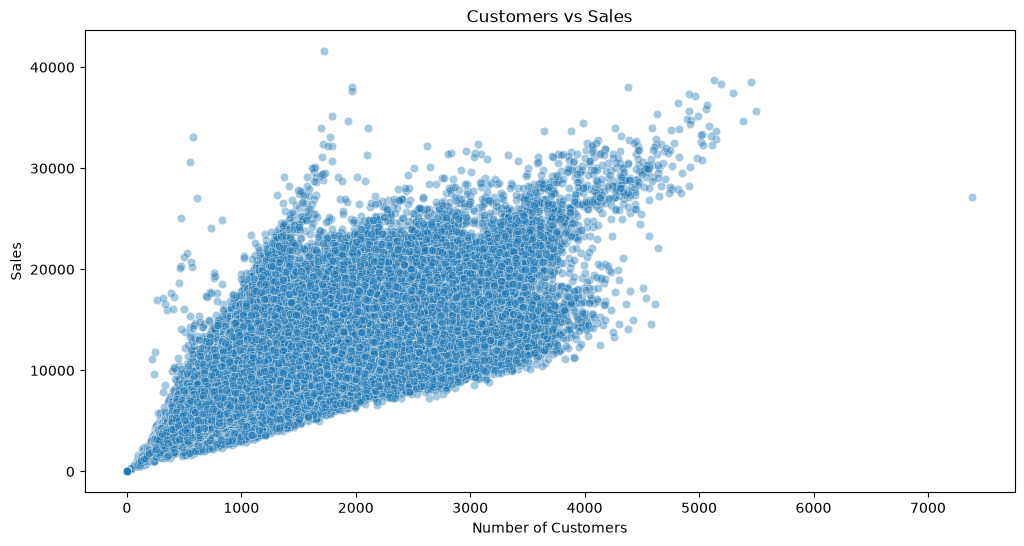

In [23]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=pricing_df,
    x="Customers",
    y="Sales",
    alpha=0.4
)

plt.title("Customers vs Sales")
plt.xlabel("Number of Customers")
plt.ylabel("Sales")

plt.show()

Correlation Heatmap

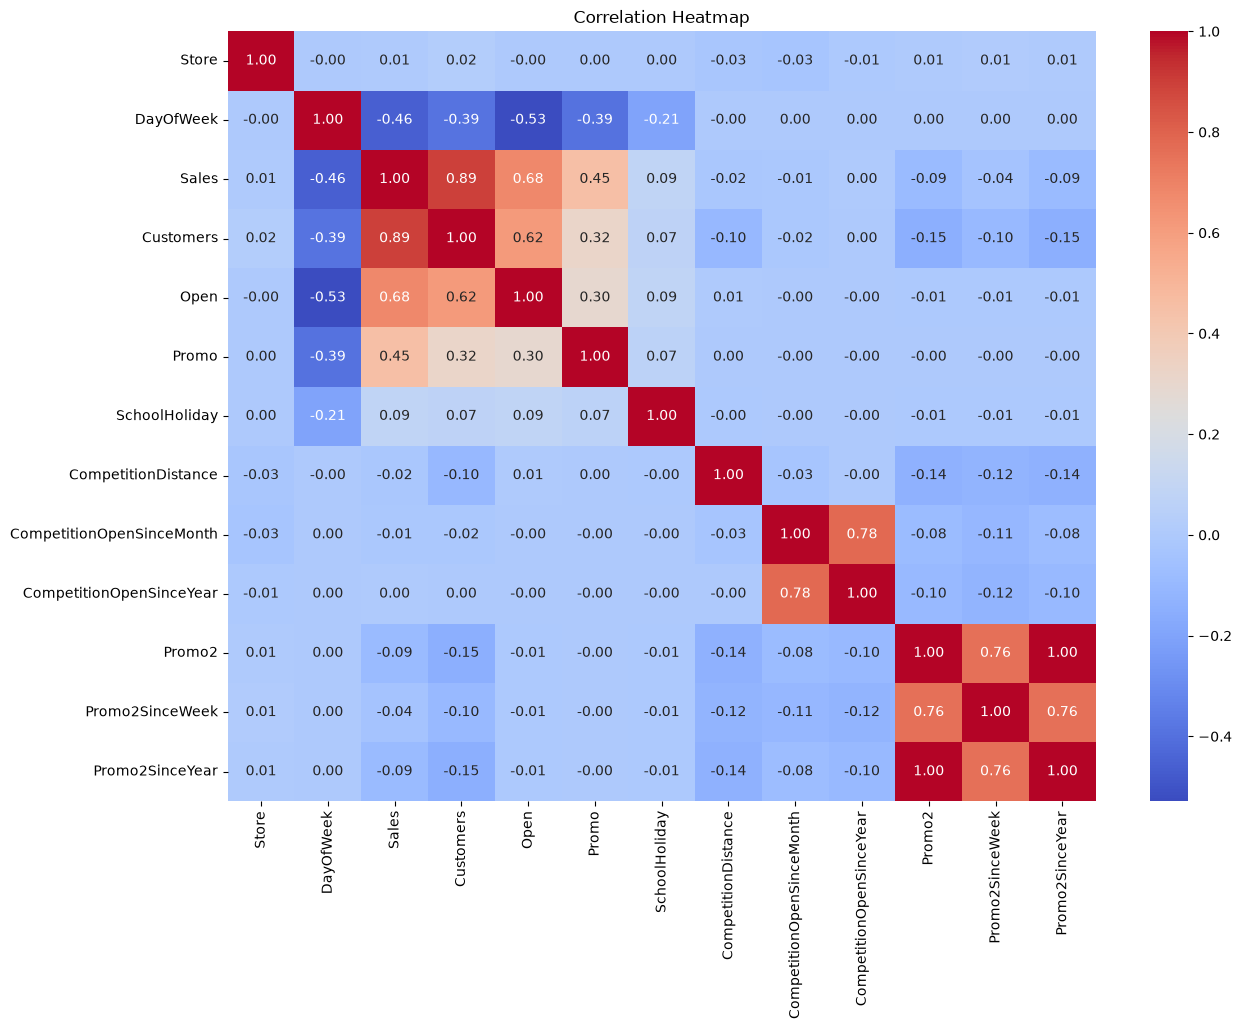

In [ ]:

numeric_df = pricing_df.select_dtypes(include=["int64", "float64"])

correlation_matrix = numeric_df.corr()

plt.figure(figsize=(14,10))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

Business Question

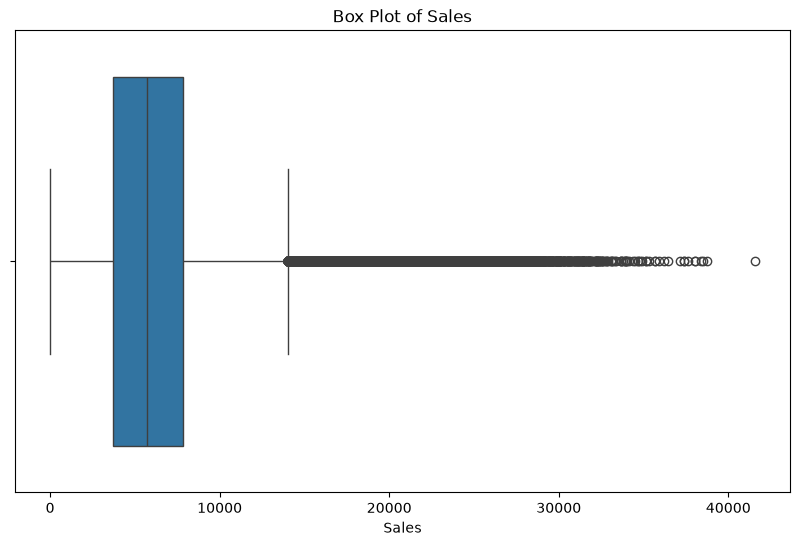

In [26]:
plt.figure(figsize=(10,6))

sns.boxplot(
    x=pricing_df["Sales"]
)

plt.title("Box Plot of Sales")

plt.show()

# Exploratory Data Analysis Summary

### Key Findings

- Sales distribution is positively skewed with several high-value outliers.
- Sales vary significantly over time, indicating seasonal demand patterns.
- Promotional campaigns are associated with higher average sales.
- Store type and assortment influence sales performance.
- Customer count shows a strong positive relationship with sales.
- Competition distance has a relatively weak relationship with sales.
- Correlation analysis identified the most influential numerical features for predicting sales.
- Outliers were retained because they represent genuine business scenarios rather than data errors.